# Data Loading, Cleaning, and Feature Engineering

## Our core research question:

> Can we accurately predict apartment prices in Buenos Aires based on characteristics like size, type, and location?

Answering that question is a three-stage process, all of which this lesson covers:

1. **Clean, structured data** — raw data is rarely machine-learning-ready straight from the source.
2. **Thoughtful feature engineering** — transforming raw columns into mathematical inputs a model can actually use.
3. **A proper train-test split** — ensuring our model is evaluated on data it has never seen during training.

---
## 1. Import and Merge Multiple CSV Files

In [41]:
import pandas as pd
import numpy as np
from glob import glob

datasets = glob("../data/buenos-aires-real-estate-*.csv")
datasets

['../data\\buenos-aires-real-estate-1.csv',
 '../data\\buenos-aires-real-estate-2.csv',
 '../data\\buenos-aires-real-estate-3.csv',
 '../data\\buenos-aires-real-estate-4.csv',
 '../data\\buenos-aires-real-estate-5.csv']

In [20]:
files = []

for x in datasets:
    data = pd.read_csv(x)  
    files.append(data)

len(files)

5

In [21]:
df = pd.concat(files, ignore_index=True)
df.head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
1,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...,NaN,250000.0,USD,3790600.0,250000.0,117.0,120.0,2136.752137,2083.333333,NaN,4.0,NaN,http://ramos-mejia.properati.com.ar/s7pd_venta...
2,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Morón|Cast...,"-34.6497002,-58.658073",410000.0,USD,6216584.0,410000.0,410.0,220.0,1000.000000,1863.636364,NaN,NaN,NaN,http://castelar-moron.properati.com.ar/11vgn_v...
3,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5957086,-58.5669503",180000.0,USD,2729232.0,180000.0,200.0,135.0,900.000000,1333.333333,NaN,5.0,NaN,http://tres-de-febrero.properati.com.ar/7f7u_v...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...


The loop above works, but we can make it more concise and reusable by converting it into a function and replacing the for loop with list comprehension.

In [46]:
def merged_files(data):
    return pd.concat([pd.read_csv(file) for file in glob(data)], ignore_index=True)

merged_files("../data/buenos-aires-real-estate-*.csv").info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

---

## 2. Data Cleaning
Our Buenos Aires dataset, now merged into a single DataFrame of over 43,000 rows and 16 columns, has several structural issues that must be addressed before we can train a reliable model.

**The problems we need to solve:**

| Problem | Effect on model if ignored |
|---------|---------------------------|
| **Market heterogeneity** — listings span multiple property types and cities | Model learns inconsistent patterns; predictions are mediocre everywhere |
| **Extreme outliers** — unusual surface area values | Regression coefficients bend toward extreme cases, reducing accuracy for typical properties |
| **Missing values** — some columns are >50% empty | Filling with mean/median invents data; better to drop and avoid noise |
| **Redundant features** — highly correlated columns | Model cannot isolate individual feature effects; coefficients become unstable |
| **String-encoded numbers** — coordinates stored as `"-34.60,-58.38"` | Cannot be used in matrix multiplication until split and cast to float |
| **Data leakage** — price-derived columns in the feature set | Model "cheats" by using the answer; fails completely on new listings |

We will tackle each issue in sequence, then bundle all cleaning steps into a single `clean_files()` master function.

### 2.1 Filter to Capital Federal Only

> **Why Filter to Capital Federal?**
>
> The raw dataset spans **Capital Federal** (the autonomous city of Buenos Aires) and **Greater Buenos Aires (GBA)** — two fundamentally different real estate markets that should not be modeled together.
> Mixing them produces a **heterogeneous dataset** — a model trained on both would be mediocre at predicting in either market, because the pricing logic differs. One linear equation cannot simultaneously capture urban Palermo dynamics and suburban La Matanza dynamics.
>
**Additional filters:**
 - **Apartments only** — houses and commercial spaces follow different pricing mechanics (lot size, zoning, business revenue potential)
- **Price < $400,000** — caps the range to typical residential buyers, excluding luxury outliers whose prices are driven by factors our features do not capture

In [48]:
(
    df
    .loc[lambda x: x["place_with_parent_names"].str.contains("Capital Federal")]
    .query('property_type == "apartment"')
    .query('price_aprox_usd < 400_000') 
)

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.00,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.60,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.80,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.00,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.60,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42990,sell,apartment,|Argentina|Capital Federal|Liniers|,"-34.6395276,-58.5196662",290000.0,USD,4397096.00,290000.0,93.0,83.0,3118.279570,3493.975904,NaN,4.0,NaN,http://liniers.properati.com.ar/t11h_venta_dep...
42997,sell,apartment,|Argentina|Capital Federal|Palermo|,"-34.5978249,-58.4164389",150000.0,USD,2274360.00,150000.0,92.0,45.0,1630.434783,3333.333333,NaN,1.0,1000.0,http://palermo.properati.com.ar/zowv_venta_dep...
43001,sell,apartment,|Argentina|Capital Federal|Mataderos|,"-34.6522327,-58.4907391",65000.0,USD,985556.00,65000.0,42.0,42.0,1547.619048,1547.619048,NaN,2.0,1000.0,http://mataderos.properati.com.ar/11zcp_venta_...
43002,sell,apartment,|Argentina|Capital Federal|Mataderos|,"-34.648761,-58.50018",91440.0,USD,1386449.85,91440.0,NaN,48.0,NaN,1905.000000,6.0,2.0,NaN,http://mataderos.properati.com.ar/xlo5_venta_d...


Wrapping the filtering logic into a reusable function called `filter_df`. The function accepts a DataFrame called `data` and returns the filtered version.

In [49]:
def filter_df(data):
    return (
        data
        .loc[lambda x: x["place_with_parent_names"].str.contains("Capital Federal")]
        .query('property_type == "apartment"')
        .query('price_aprox_usd < 400_000')
           )

### 2.2 Handling Outliers

Even within Capital Federal apartments under $400K, the surface area column (`surface_covered_in_m2`) still contains extreme values that would distort the model's learned coefficients.

In [25]:
def outliers_df(data):
    return (
        data
        .loc[lambda x: x["surface_covered_in_m2"].between(
            x["surface_covered_in_m2"].quantile(0.1),
            x["surface_covered_in_m2"].quantile(0.9)
        )] 
    )

# Test the function
check_outliers = outliers_df(df)
check_outliers.info()

<class 'pandas.DataFrame'>
Index: 29247 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   29247 non-null  str    
 1   property_type               29247 non-null  str    
 2   place_with_parent_names     29247 non-null  str    
 3   lat-lon                     23338 non-null  str    
 4   price                       26963 non-null  float64
 5   currency                    26962 non-null  str    
 6   price_aprox_local_currency  26963 non-null  float64
 7   price_aprox_usd             26963 non-null  float64
 8   surface_total_in_m2         22538 non-null  float64
 9   surface_covered_in_m2       29247 non-null  float64
 10  price_usd_per_m2            18931 non-null  float64
 11  price_per_m2                26962 non-null  float64
 12  floor                       5441 non-null   float64
 13  rooms                       18480 non-null  flo

### 2.3 Extracting Features from String Columns

Our dataset contains two columns that store **multiple pieces of information bundled into a single string**. A machine learning model cannot work with strings directly — we need to extract the numeric and categorical information encoded inside them.

**What is buried in each column?**

| Column | Raw value example | Hidden information | Target features |
|--------|-------------------|--------------------|-----------------|
| `"lat-lon"` | `"-34.6037,-58.3816"` | Latitude and longitude as a comma-separated pair | `lat` (float), `lon` (float) |
| `"place_with_parent_names"` | `"Argentina\|Buenos Aires\|Capital Federal\|Palermo\|..."` | Hierarchical location path, pipe-separated | `neighborhood` (string, segment index 3) |

**Why neighborhood as a separate feature?**

Coordinates capture continuous geographic variation, but `neighborhood` captures *discrete categorical identity* - the local amenity profile, prestige, and community character of a named area. These are complementary signals: two apartments 500 meters apart might be in different neighborhoods with meaningfully different price expectations.

In [50]:
def modify_cols(data):
    return (
        data
        .assign(
            lat=lambda x: x["lat-lon"].str.split(",", expand=True)[0].astype(float),      
            lon=lambda x: x["lat-lon"].str.split(",", expand=True)[1].astype(float),      
            neighborhood=lambda x: x["place_with_parent_names"].str.split("|", expand=True)[3]
        )
    )

check_cols = modify_cols(df)
check_cols.info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

### 2.4 Missing Values Analysis

We need to understand where our data has gaps.

**Our approach:** Visualize first, decide second.

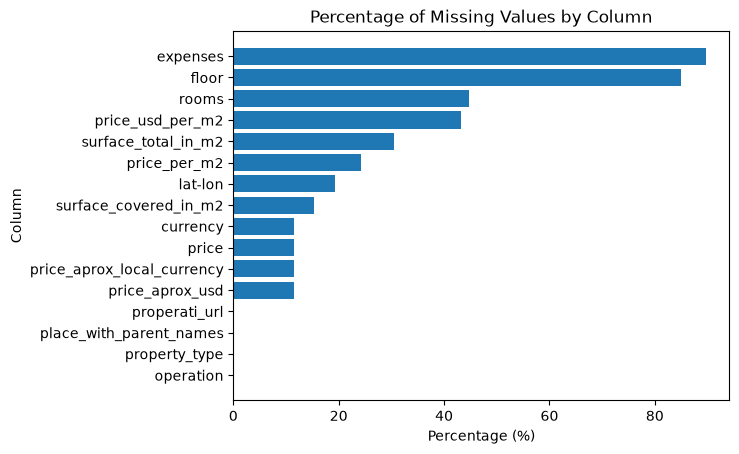

In [51]:
import matplotlib.pyplot as plt

# Percentage of missing values by column
nan_columns_percentage = (df.isna().sum(axis=0) * 100 / len(df)).sort_values()

fig, ax = plt.subplots()

# Horizontal bar plot
ax.barh(y=nan_columns_percentage.index, width=nan_columns_percentage)
ax.set_title('Percentage of Missing Values by Column')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Column')
plt.show()

The bar chart shows the **percentage of missing values per column**. Key observations:

- `expenses` and `floor` are missing more than 50% of their values
- `rooms` is missing around 40%
- `price_aprox_usd` — our target — has some missing values but is mostly complete

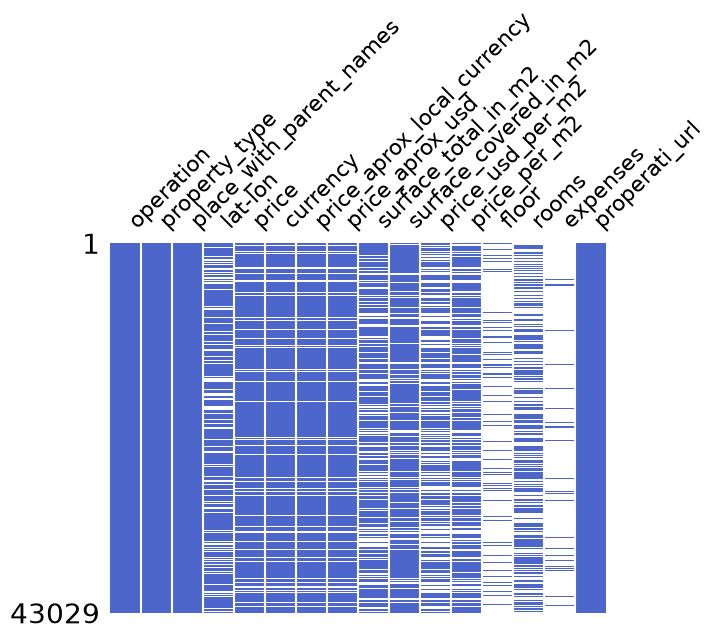

In [52]:
import missingno as msno

fig, ax = plt.subplots()
msno.matrix(df, color=(0.3, 0.4, 0.8), ax=ax,sparkline=False)
plt.show()

**Reading the `missingno` Matrix**

- Columns like `operation`, `property_type`, and `currency` are **solid blue** — fully complete 
- `currency`, `price_aprox_local_currency`, and `price_aprox_usd` tend to be **missing together** — these co-occur in rows where no price information was recorded at all
- `expenses` has the most white space, followed by `floor` and `rooms`

**Decision:** Keep `price_aprox_usd` (our target variable) and drop all other price-related and high-missingness columns. The pattern of co-occurrence with other price columns confirms that rows missing `price_aprox_usd` are simply unpriced listings — we cannot recover them.

### 2.5 Multicollinearity Analysis

After resolving missing values, we face a different problem: some columns that *are* present may be measuring nearly the same thing, making them redundant and potentially harmful to the model.

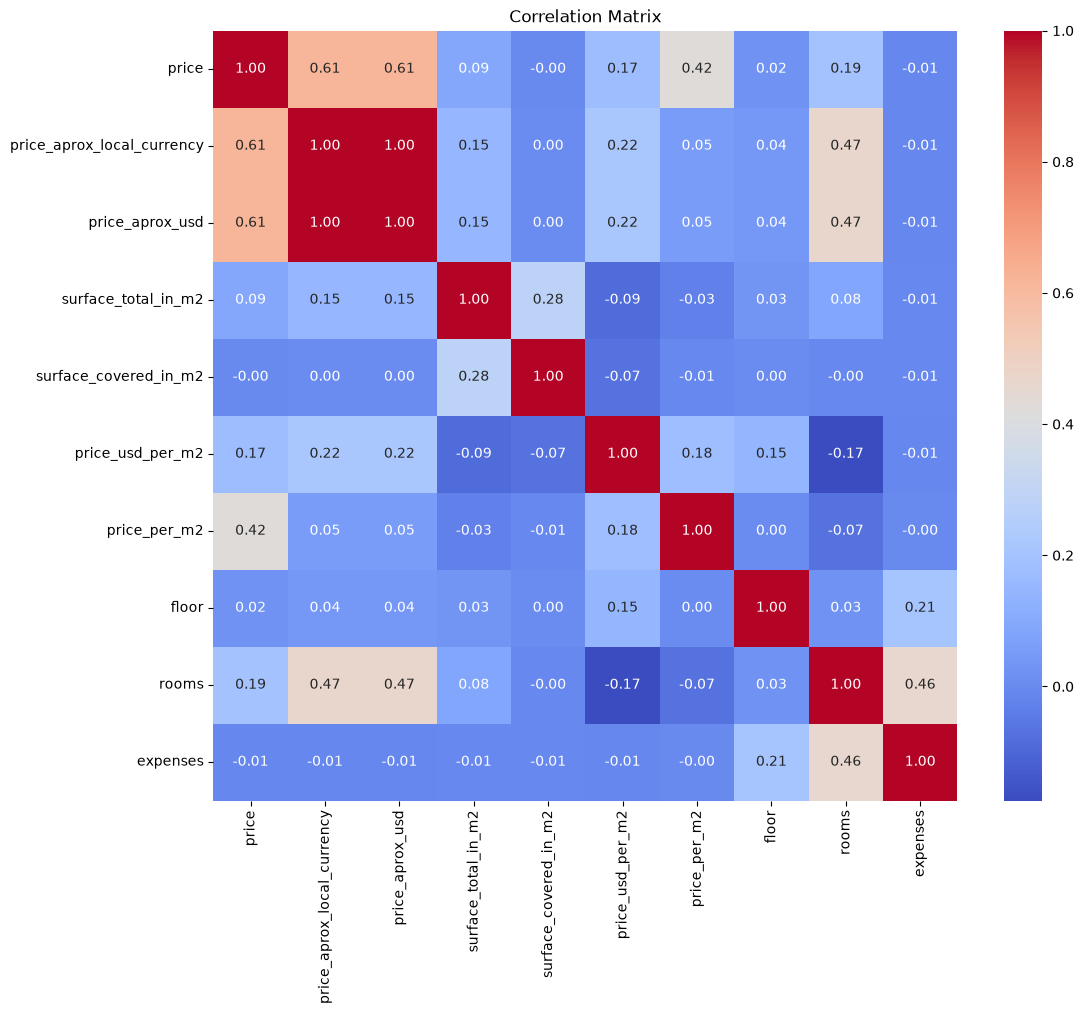

In [53]:
import seaborn as sns

# Calculate correlation matrix for numeric columns
corr_matrix = df.select_dtypes(include='number').corr()  

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

### 2.6 Dropping Unnecessary Columns

Based on the missing value analysis and the multicollinearity heatmap, we now have a principled list of columns to remove. Each drop has a specific reason — this is not arbitrary data reduction.

> **Principled Column Removal — Full Rationale**
>
> | Category | Columns | Why they must go |
> |----------|---------|-----------------|
> | **High missingness (>50%)** | `expenses`, `floor`, `rooms` | Imputing >50% of values creates more fictional data than real; any model trained on them would learn noise |
> | **Data leakage** | `price`, `price_aprox_local_currency`, `price_usd_per_m2`, `price_per_m2` | These columns are **computed from the target price**. If left in, the model learns to predict price by reading price — achieving perfect training accuracy but being completely useless on new listings where these derived columns do not exist |
> | **Multicollinearity** | `surface_total_in_m2` | High Correlation with `surface_covered_in_m2` — keeping both makes both coefficients unstable and uninterpretable |
> | **Unique identifiers** | `properati_url` | Every listing has a unique URL — the model would memorize specific URLs rather than learning generalizable price patterns. A 0% test-set accuracy waiting to happen |
> | **Already extracted** | `lat-lon`, `place_with_parent_names` | We extracted `lat`, `lon`, and `neighborhood` from these — the original string columns are now redundant |
> | **Single-value columns** | `operation`, `property_type`, `currency` | We filtered to one value of each (`"sell"`, `"apartment"`, `"USD"`). A column with zero variance provides zero information to the model |

**Data leakage deserves special emphasis:** Real estate platform cannot include `price_usd_per_m2` in a new listing before it has been sold.

In [54]:
drop_cols = [
    "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2",
    "price_per_m2", "operation", "property_type", "currency",
    "properati_url", "surface_total_in_m2"
]

### 2.7 The Master Cleaning Function

In [31]:
def clean_files(file_path):
    #Final function to complete the cleaning process
    drop_cols = [
        "lat-lon", "place_with_parent_names",
        "floor", "expenses", "rooms", "price",
        "price_aprox_local_currency", "price_usd_per_m2",
        "price_per_m2", "operation", "property_type", "currency",
        "properati_url", "surface_total_in_m2"
    ]

    return (
        merged_files(file_path)      # Initial DataFrame
        .pipe(filter_df)             # Filter to Capital Federal apartments
        .pipe(outliers_df)           # Remove outliers
        .pipe(modify_cols)           # Create new columns
        .drop(columns=drop_cols)     # Drop unnecessary columns
        .dropna()                    # Drop rows with missing values
    )

clean_df = clean_files("../data/buenos-aires-real-estate-*.csv")
clean_df.info()
clean_df

<class 'pandas.DataFrame'>
Index: 6247 entries, 4 to 43021
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighborhood           6247 non-null   str    
dtypes: float64(4), str(1)
memory usage: 292.8 KB


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,Constitución
41,90000.0,50.0,-34.610610,-58.412511,Once
...,...,...,...,...,...
42990,290000.0,83.0,-34.639528,-58.519666,Liniers
42997,150000.0,45.0,-34.597825,-58.416439,Palermo
43001,65000.0,42.0,-34.652233,-58.490739,Mataderos
43002,91440.0,48.0,-34.648761,-58.500180,Mataderos


---

## 3. Split Data into Features and Target

Before we can encode categorical variables or train any model, we must separate the DataFrame into two distinct components that scikit-learn expects: the **feature matrix** and the **target vector**.

In [55]:
target = "price_aprox_usd"
features = [cols for cols in clean_df.columns if cols != target]

y = clean_df[target]  
X = clean_df[features]  

print(f"y shape: {y.shape}")
print(f"X shape: {X.shape}")

y shape: (6247,)
X shape: (6247, 4)


Neighborhood is a categorical (text) feature. Models need numbers, so it will be one-hot encoded in notebook no: 3, we will use `category_encoders.OneHotEncoder` inside a scikit-learn `Pipeline`.

---
## 4. Train-Test Split in Scikit-Learn

In [57]:
from sklearn.model_selection import train_test_split

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 4997 samples
Test set: 1250 samples
